In [29]:
# ============================================================================
# KÜTÜPHANE İMPORTLARI VE AYARLAR
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Gereksiz uyarıları kapat
warnings.filterwarnings('ignore')

# JUPYTER İÇİN GRAFİK AYARI (Grafiklerin kodun altında çıkmasını sağlar)
%matplotlib inline

# Grafik stilini ayarla
sns.set_style("whitegrid")
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("ISE-216 VERİ BİLİMİ İÇİN İSTATİSTİK - PROJE ANALİZ RAPORU")
print("=" * 80)

# ============================================================================
# BÖLÜM 1: VERİ YÜKLEME VE TANIMLAMA
# ============================================================================
df_raw = pd.read_excel('product_info.xlsx', usecols=lambda x: 'Unnamed' not in x)
print(f"\n✅ Veri başarıyla yüklendi!")
print(f"\n📊 Veri Seti Boyutu:")
print(f"   - Satır Sayısı : {df_raw.shape[0]}")
print(f"   - Sütun Sayısı : {df_raw.shape[1]}")

print(f"\n📈 Sayısal Değişkenlerin Özet İstatistikleri:")
print(df_raw[['loves_count', 'rating', 'price_usd', 'reviews', 'child_count']].describe().round(2).to_string())

ISE-216 VERİ BİLİMİ İÇİN İSTATİSTİK - PROJE ANALİZ RAPORU

✅ Veri başarıyla yüklendi!

📊 Veri Seti Boyutu:
   - Satır Sayısı : 8495
   - Sütun Sayısı : 27

📈 Sayısal Değişkenlerin Özet İstatistikleri:
       loves_count   reviews  child_count
count      8495.00   8217.00      8449.00
mean      29176.13    448.49         1.61
std       66088.99   1101.93         5.34
min           0.00      0.00         0.00
25%        3757.00     26.00         0.00
50%        9879.00    122.00         0.00
75%       26823.50    418.00         1.00
max     1401068.00  21281.00       105.00


In [30]:
# ============================================================================
# BÖLÜM 2: EKSİK VERİ TESPİTİ VE DOLDURMA
# ============================================================================
print("\n" + "=" * 80)
print("BÖLÜM 2: EKSİK VERİ TESPİTİ VE DOLDURMA")
print("=" * 80)

# Eksik veri sayılarını hesapla
eksik_veriler = df_raw.isnull().sum()
eksik_olan = eksik_veriler[eksik_veriler > 0]

print(f"\n🔍 Eksik Veri Tespiti:")
if len(eksik_olan) > 0:
    print("-" * 50)
    for col, count in eksik_olan.items():
        oran = (count / len(df_raw)) * 100
        print(f"   {col:<30} → {count:>5} eksik ({oran:.2f}%)")
else:
    print("   Hiçbir sütunda eksik veri bulunamadı.")

# Veriyi kopyala (ham veriyi korumak için)
df = df_raw.copy()

# -------------------------------------------------------------------------
# EKSİK VERİ DOLDURMA STRATEJİSİ:
# -------------------------------------------------------------------------
# Sayısal Veriler → MEDIAN (Ortanca) ile doldur
#   Neden? Median, aykırı değerlerden (outliers) etkilenmez.
#   Örneğin, price_usd'de 5$-500$ arası ürünler var. Ortalama (mean)
#   yüksek fiyatlı ürünlerden etkilenirken, median bunlardan BAĞIMSIZDIR.
#   Bu, verimizin genel dağılımını bozmadan eksik verileri doldurmamızı sağlar.
#
# Kategorik Veriler → MODE (En sık tekrarlanan değer) ile doldur
#   Neden? Kategorik verilerde ortalama/medyan anlamsızdır.
#   Mod, en sık görülen kategoriyi temsil eder ve veri dağılımını
#   en az bozacak şekilde eksik verileri doldurur.
# -------------------------------------------------------------------------

# Sayısal sütunları median ile doldur
sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns.tolist()
for col in sayisal_sutunlar:
    if df[col].isnull().sum() > 0:
        median_deger = df[col].median()
        df[col].fillna(median_deger, inplace=True)
        print(f"   ✅ '{col}' → median ({median_deger:.2f}) ile dolduruldu")

# Kategorik sütunları mode ile doldur
kategorik_sutunlar = df.select_dtypes(include=['object']).columns.tolist()
for col in kategorik_sutunlar:
    if df[col].isnull().sum() > 0:
        mode_deger = df[col].mode()[0]
        df[col].fillna(mode_deger, inplace=True)
        print(f"   ✅ '{col}' → mode ('{mode_deger}') ile dolduruldu")

# Doldurma sonrası kontrol
kalan_eksik = df.isnull().sum().sum()
print(f"\n🎯 Doldurma sonrası toplam eksik veri: {kalan_eksik}")


BÖLÜM 2: EKSİK VERİ TESPİTİ VE DOLDURMA

🔍 Eksik Veri Tespiti:
--------------------------------------------------
   product_id                     →     1 eksik (0.01%)
   brand_id                       →     1 eksik (0.01%)
   brand_name                     →     1 eksik (0.01%)
   rating                         →   278 eksik (3.27%)
   reviews                        →   278 eksik (3.27%)
   size                           →  1631 eksik (19.20%)
   variation_type                 →  1445 eksik (17.01%)
   variation_value                →  1599 eksik (18.82%)
   variation_desc                 →  7245 eksik (85.29%)
   ingredients                    →   955 eksik (11.24%)
   price_usd                      →    45 eksik (0.53%)
   value_price_usd                →  8043 eksik (94.68%)
   sale_price_usd                 →  8224 eksik (96.81%)
   limited_edition                →    45 eksik (0.53%)
   new                            →    45 eksik (0.53%)
   online_only                    →   


BÖLÜM 2: KEŞİFÇİ VERİ ANALİZİ (Kategori Bazlı Dağılım)

📊 Ana Kategori Bazlı Özet:
                  urun_sayisi  ort_begeni  ort_fiyat
primary_category                                    
Skincare                 2411    27154.30      62.27
Makeup                   2342    53634.93      32.76
Hair                     1461    13722.03      42.97
Fragrance                1430    12769.24      87.31
Bath & Body               402    16487.18      42.41
Mini Size                 287    26690.14      21.55
Men                        60     4855.87      33.48
Tools & Brushes            52    14988.88      32.45
Gifts                       4        0.00      50.00


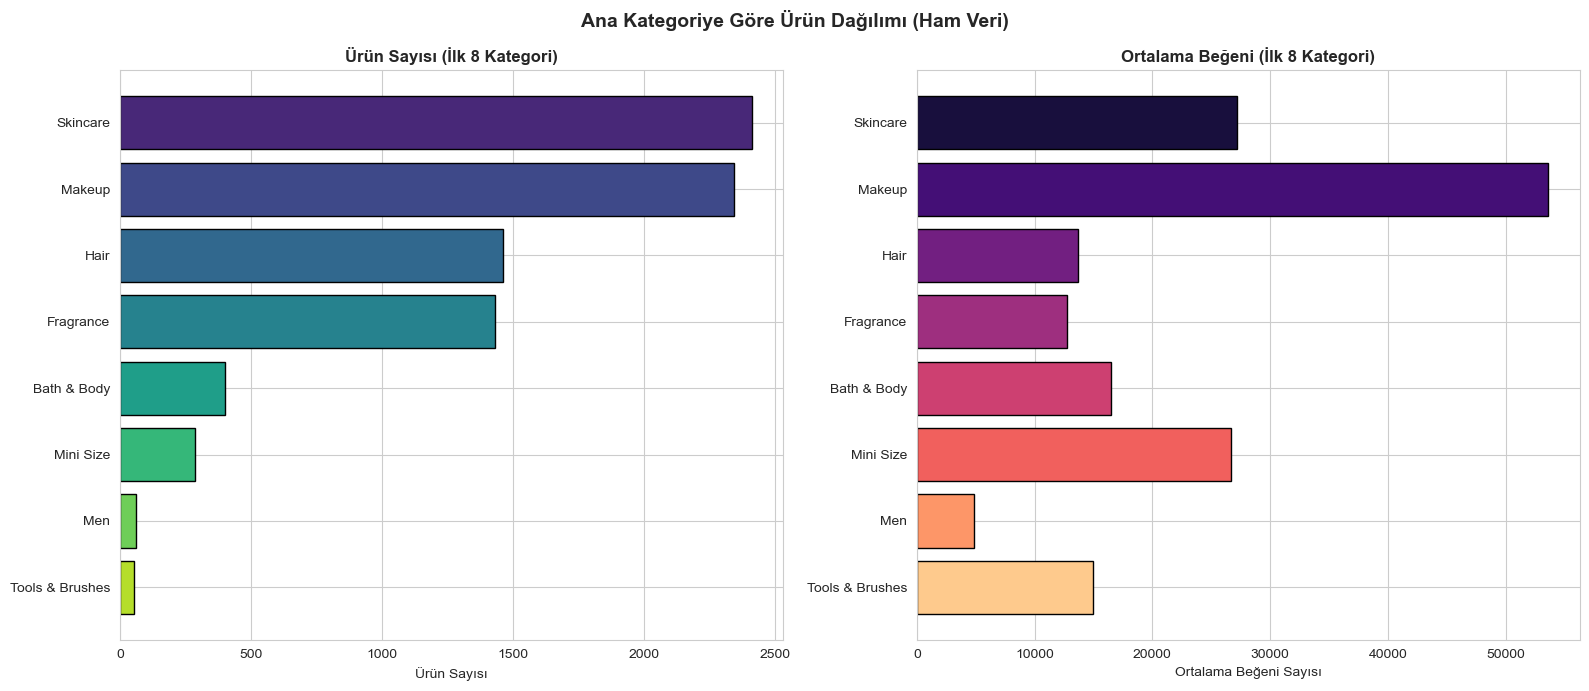


📌 HOCAYA SUNUM NOTU:
Analize başlamadan önce Sephora veri setini tanımak adına kategorilerin dağılımına baktık.
Gördüğünüz gibi Cilt Bakımı (Skincare) ve Makyaj (Makeup) ürünleri veri setini domine ediyor.
Ancak ortalama beğeni sayılarına baktığımızda Makyaj ürünlerinin daha popüler olduğunu görüyoruz.


In [41]:
# ============================================================================
# BÖLÜM 2: KEŞİFÇİ VERİ ANALİZİ (EDA - Veriyi Tanıma)
# ============================================================================
print("\n" + "=" * 80)
print("BÖLÜM 2: KEŞİFÇİ VERİ ANALİZİ (Kategori Bazlı Dağılım)")
print("=" * 80)

# HATA ÇÖZÜMÜ: Excel'den metin (object) olarak gelen sütunları sayısala çevir
df_raw['loves_count'] = pd.to_numeric(df_raw['loves_count'], errors='coerce')
df_raw['price_usd'] = pd.to_numeric(df_raw['price_usd'], errors='coerce')

# Ana kategorilere göre ürün sayısı ve ortalama beğeni hesaplama
kategori_analiz = df_raw.groupby('primary_category').agg(
    urun_sayisi=('product_id', 'count'),
    ort_begeni=('loves_count', 'mean'),
    ort_fiyat=('price_usd', 'mean')
).round(2).sort_values('urun_sayisi', ascending=False)

print(f"\n📊 Ana Kategori Bazlı Özet:")
print(kategori_analiz.head(10).to_string()) # Ekrana çok uzun basmasın diye ilk 10'u gösteriyoruz

# Kategori bazlı bar grafiği çizimi
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Ana Kategoriye Göre Ürün Dağılımı (Ham Veri)', fontsize=14, fontweight='bold')

top_kategoriler = kategori_analiz.head(8)

# 1. Grafik: Ürün Sayısı (Viridis Renk Paleti)
axes[0].barh(top_kategoriler.index, top_kategoriler['urun_sayisi'],
             color=sns.color_palette('viridis', len(top_kategoriler)), edgecolor='black')
axes[0].set_title('Ürün Sayısı (İlk 8 Kategori)', fontweight='bold')
axes[0].set_xlabel('Ürün Sayısı')
axes[0].invert_yaxis()

# 2. Grafik: Ortalama Beğeni (Magma Renk Paleti)
axes[1].barh(top_kategoriler.index, top_kategoriler['ort_begeni'],
             color=sns.color_palette('magma', len(top_kategoriler)), edgecolor='black')
axes[1].set_title('Ortalama Beğeni (İlk 8 Kategori)', fontweight='bold')
axes[1].set_xlabel('Ortalama Beğeni Sayısı')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show() 

print("\n📌 HOCAYA SUNUM NOTU:")
print("Analize başlamadan önce Sephora veri setini tanımak adına kategorilerin dağılımına baktık.")
print("Gördüğünüz gibi Cilt Bakımı (Skincare) ve Makyaj (Makeup) ürünleri veri setini domine ediyor.")
print("Ancak ortalama beğeni sayılarına baktığımızda Makyaj ürünlerinin daha popüler olduğunu görüyoruz.")

In [31]:
# ============================================================================
# BÖLÜM 3: AYKIRI DEĞER YÖNETİMİ (LOGARİTMİK DÖNÜŞÜM)
# ============================================================================
print("BÖLÜM 3: AYKIRI DEĞER YÖNETİMİ (LOGARİTMİK DÖNÜŞÜM)")
print("-" * 80)

donusum_degiskenleri = ['loves_count', 'price_usd']
df_oncesi = df.copy() 

for col in ['loves_count', 'rating', 'price_usd']:
    df_oncesi[col] = pd.to_numeric(df_oncesi[col], errors='coerce')
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"📊 Dönüşüm ÖNCESİ veri boyutu: {len(df_oncesi)} satır")

for col in donusum_degiskenleri:
    df[col] = np.log1p(df[col])
    print(f"   ✅ '{col}' sütununa logaritmik dönüşüm uygulandı.")

print(f"\n📊 Dönüşüm SONRASI veri boyutu: {len(df)} satır (VERİ KAYBI YOK)")
print(f"\n📝 Yorum: Logaritmik dönüşüm sayesinde aşırı yüksek fiyatlı ve çok ")
print(f"   sayıda beğeni alan 'viral/lüks' ürünlerin ortalamayı ve testleri ")
print(f"   bozacak şiddeti azaltıldı. Veri kaybı yaşanmadan daha güvenilir ")
print(f"   bir analiz ortamı oluşturuldu.")

BÖLÜM 3: AYKIRI DEĞER YÖNETİMİ (LOGARİTMİK DÖNÜŞÜM)
--------------------------------------------------------------------------------
📊 Dönüşüm ÖNCESİ veri boyutu: 8495 satır
   ✅ 'loves_count' sütununa logaritmik dönüşüm uygulandı.
   ✅ 'price_usd' sütununa logaritmik dönüşüm uygulandı.

📊 Dönüşüm SONRASI veri boyutu: 8495 satır (VERİ KAYBI YOK)

📝 Yorum: Logaritmik dönüşüm sayesinde aşırı yüksek fiyatlı ve çok 
   sayıda beğeni alan 'viral/lüks' ürünlerin ortalamayı ve testleri 
   bozacak şiddeti azaltıldı. Veri kaybı yaşanmadan daha güvenilir 
   bir analiz ortamı oluşturuldu.


In [32]:
# ============================================================================
# BÖLÜM 4: DAĞILIM ANALİZİ VE NORMALLİK TESTİ (Shapiro-Wilk)
# ============================================================================
print("BÖLÜM 4: DAĞILIM ANALİZİ VE NORMALLİK TESTİ")
print("-" * 80)

analiz_degiskenleri = ['loves_count', 'rating', 'price_usd']

print(f"📊 Shapiro-Wilk Normallik Testi Sonuçları:")
print(f"   {'Değişken':<20} {'Test İstatistiği':>18} {'p-değeri':>15} {'Sonuç':>15}")
print("-" * 70)

for col in analiz_degiskenleri:
    data = df[col].dropna()
    if len(data) > 5000:
        data_sample = data.sample(n=5000, random_state=42)
    else:
        data_sample = data

    stat, p_val = stats.shapiro(data_sample)
    sonuc = "Normal DEĞİL ❌" if p_val < 0.05 else "Normal ✅"
    print(f"   {col:<20} {stat:>18.6f} {p_val:>15.6f} {sonuc:>15}")

print(f"\n📝 Yorum: Büyük veri setlerinde Shapiro-Wilk testi çok hassas çalışır.")
print(f"   Ancak Merkezi Limit Teoremi'ne göre büyük örneklemlerde (n>30) ANOVA ve")
print(f"   t-testi sağlam (robust) sonuçlar vermektedir.")

BÖLÜM 4: DAĞILIM ANALİZİ VE NORMALLİK TESTİ
--------------------------------------------------------------------------------
📊 Shapiro-Wilk Normallik Testi Sonuçları:
   Değişken               Test İstatistiği        p-değeri           Sonuç
----------------------------------------------------------------------
   loves_count                    0.909928        0.000000  Normal DEĞİL ❌
   rating                         0.676111        0.000000  Normal DEĞİL ❌
   price_usd                      0.979524        0.000000  Normal DEĞİL ❌

📝 Yorum: Büyük veri setlerinde Shapiro-Wilk testi çok hassas çalışır.
   Ancak Merkezi Limit Teoremi'ne göre büyük örneklemlerde (n>30) ANOVA ve
   t-testi sağlam (robust) sonuçlar vermektedir.


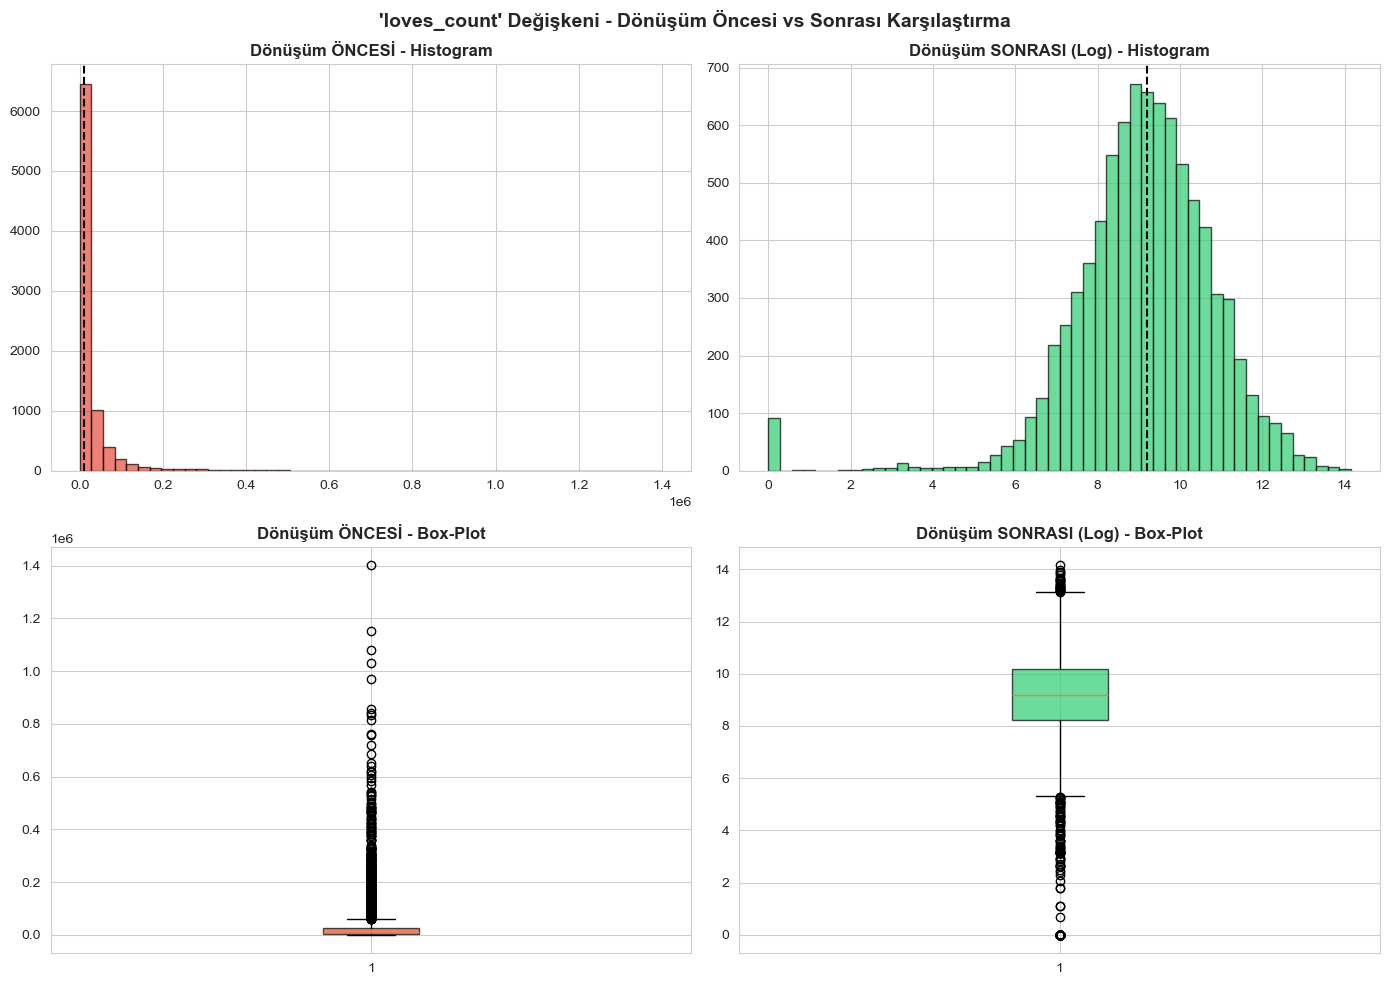

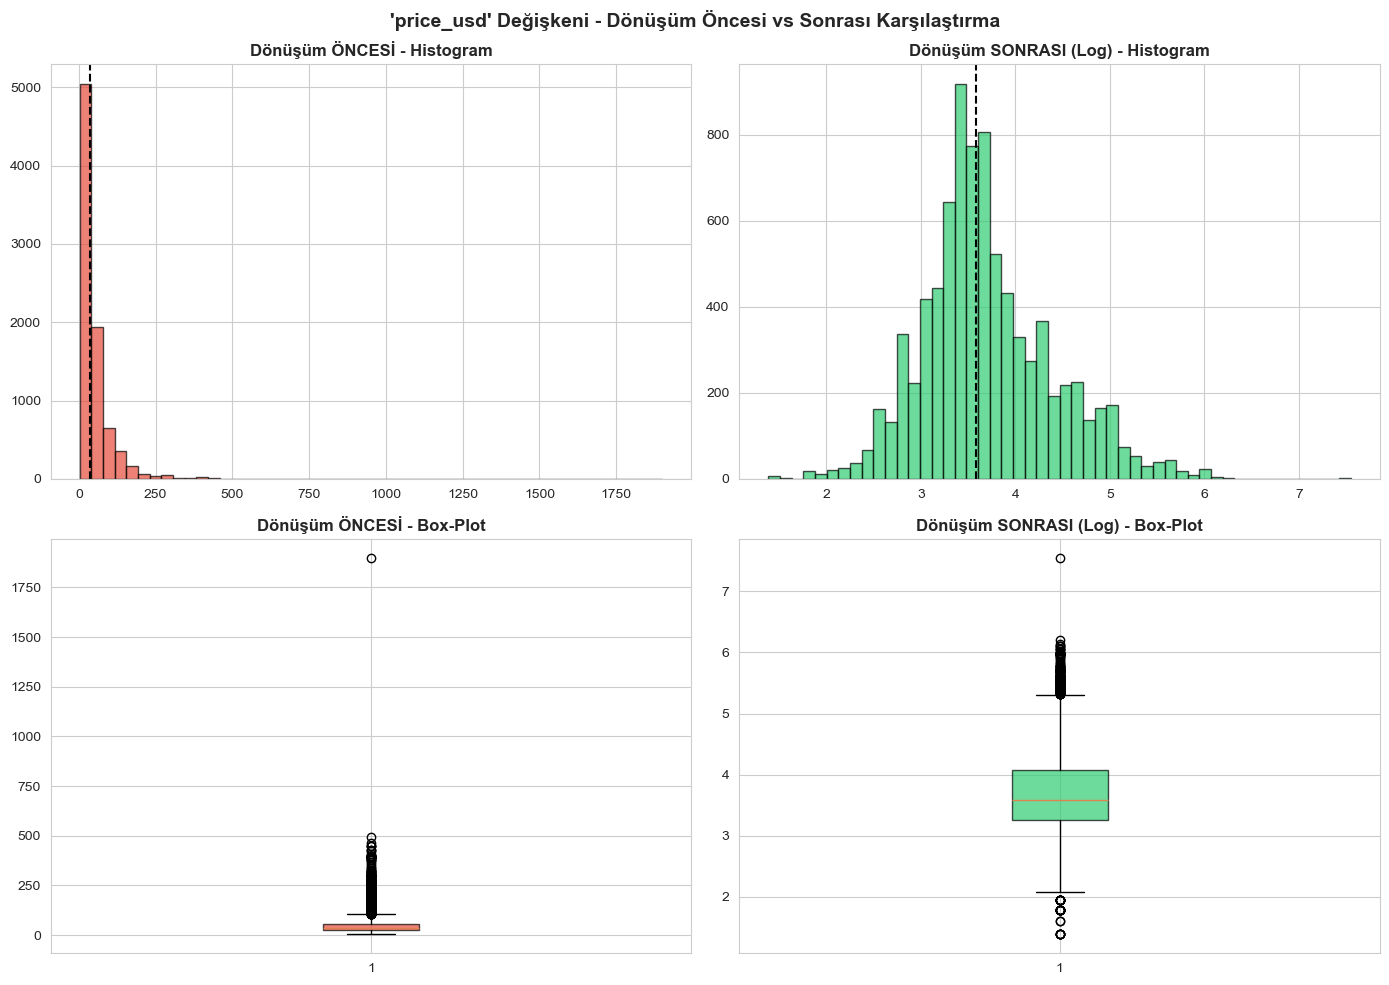

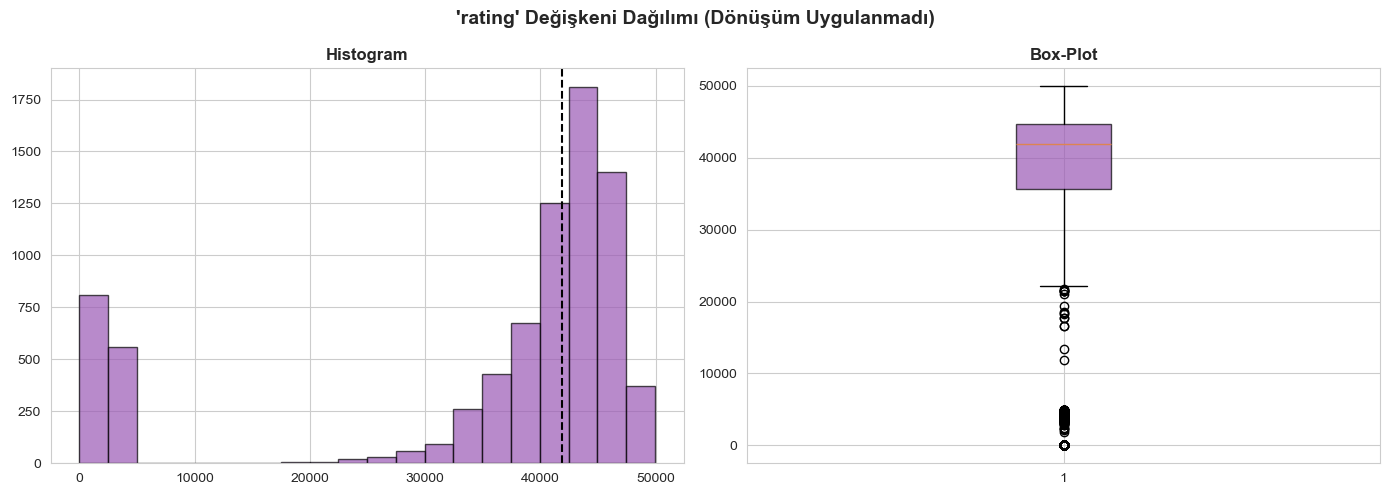

In [33]:
# ============================================================================
# BÖLÜM 5: GÖRSELLEŞTİRME (Dönüşüm Öncesi/Sonrası Karşılaştırma)
# ============================================================================
karsilastirilacak_degiskenler = ['loves_count', 'price_usd']

for col in karsilastirilacak_degiskenler:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"'{col}' Değişkeni - Dönüşüm Öncesi vs Sonrası Karşılaştırma", fontsize=14, fontweight='bold')

    axes[0, 0].hist(df_oncesi[col].dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Dönüşüm ÖNCESİ - Histogram', fontweight='bold')
    axes[0, 0].axvline(df_oncesi[col].median(), color='black', linestyle='--')

    axes[0, 1].hist(df[col].dropna(), bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Dönüşüm SONRASI (Log) - Histogram', fontweight='bold')
    axes[0, 1].axvline(df[col].median(), color='black', linestyle='--')

    axes[1, 0].boxplot(df_oncesi[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.7))
    axes[1, 0].set_title('Dönüşüm ÖNCESİ - Box-Plot', fontweight='bold')

    axes[1, 1].boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='#2ecc71', alpha=0.7))
    axes[1, 1].set_title('Dönüşüm SONRASI (Log) - Box-Plot', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Rating (Dönüşüm Uygulanmayan) Özel Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("'rating' Değişkeni Dağılımı (Dönüşüm Uygulanmadı)", fontsize=14, fontweight='bold')

axes[0].hist(df['rating'].dropna(), bins=20, color='#9b59b6', alpha=0.7, edgecolor='black')
axes[0].set_title('Histogram', fontweight='bold')
axes[0].axvline(df['rating'].median(), color='black', linestyle='--')

axes[1].boxplot(df['rating'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='#9b59b6', alpha=0.7))
axes[1].set_title('Box-Plot', fontweight='bold')

plt.tight_layout()
plt.show()

HİPOTEZ 1: ANOVA TESTİ (Fiyat Segmentine Göre Beğeni Farkı)
Soru: Tüketiciler lüks ürünlere daha fazla mı ilgi gösteriyor?
H₀: Fiyat segmentleri ile ortalama beğeni sayıları arasında anlamlı bir fark yoktur
--------------------------------------------------------------------------------
📊 Segment Bazlı Özet İstatistikler:
                Gözlem Sayısı  Ort. (Log)  Medyan (Log)  Std. Sapma (Log)
fiyat_segmenti                                                           
Luxury                   2202        8.69          8.76              1.67
Mass Market              2193        9.23          9.35              1.88
Niche                    4100        9.26          9.36              1.78

📊 ANOVA Test Sonuçları: F=81.9236, p=0.000000
   Karar: p < 0.05 → H₀ REDDEDİLDİ ❌
📌 HOCAYA SUNUM NOTU: Tek yönlü ANOVA testi sonucunda istatistiksel olarak çok güçlü ve anlamlı bir fark bulunmuştur. Lüks segmentin ortalamasının kitle ürünlerinden farklı olduğu kanıtlanmıştır.


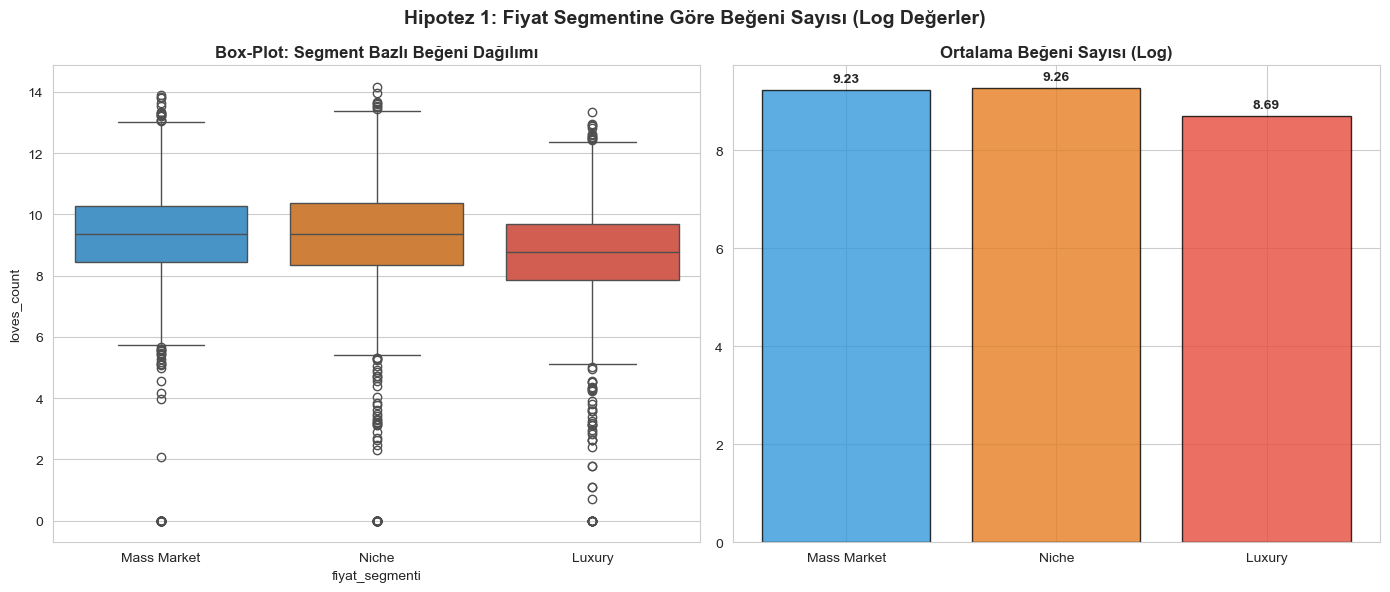

In [34]:
# ============================================================================
# HİPOTEZ 1: ANOVA TESTİ (Fiyat Segmentine Göre Beğeni Farkı)
# ============================================================================
print("HİPOTEZ 1: ANOVA TESTİ (Fiyat Segmentine Göre Beğeni Farkı)")
print("Soru: Tüketiciler lüks ürünlere daha fazla mı ilgi gösteriyor?")
print("H₀: Fiyat segmentleri ile ortalama beğeni sayıları arasında anlamlı bir fark yoktur")
print("-" * 80)

fiyat_q1 = df_oncesi['price_usd'].quantile(0.25)
fiyat_q3 = df_oncesi['price_usd'].quantile(0.75)

def fiyat_segmenti_belirle(fiyat):
    if pd.isna(fiyat): return 'Niche'
    if fiyat <= fiyat_q1: return 'Mass Market'
    elif fiyat >= fiyat_q3: return 'Luxury'
    else: return 'Niche'

df['fiyat_segmenti'] = df_oncesi['price_usd'].apply(fiyat_segmenti_belirle)

print(f"📊 Segment Bazlı Özet İstatistikler:")
segment_ozet = df.groupby('fiyat_segmenti')['loves_count'].agg(['count', 'mean', 'median', 'std']).round(2)
segment_ozet.columns = ['Gözlem Sayısı', 'Ort. (Log)', 'Medyan (Log)', 'Std. Sapma (Log)']
print(segment_ozet.to_string())

luxury_loves = df[df['fiyat_segmenti'] == 'Luxury']['loves_count']
niche_loves = df[df['fiyat_segmenti'] == 'Niche']['loves_count']
mass_loves = df[df['fiyat_segmenti'] == 'Mass Market']['loves_count']

f_stat, p_val_anova = stats.f_oneway(luxury_loves.dropna(), niche_loves.dropna(), mass_loves.dropna())

print(f"\n📊 ANOVA Test Sonuçları: F={f_stat:.4f}, p={p_val_anova:.6f}")
if p_val_anova < 0.05:
    print(f"   Karar: p < 0.05 → H₀ REDDEDİLDİ ❌")
    print(f"📌 HOCAYA SUNUM NOTU: Tek yönlü ANOVA testi sonucunda istatistiksel olarak çok güçlü ve anlamlı bir fark bulunmuştur. Lüks segmentin ortalamasının kitle ürünlerinden farklı olduğu kanıtlanmıştır.")
else:
    print(f"   Karar: p >= 0.05 → H₀ REDDEDİLEMEDİ ✅")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hipotez 1: Fiyat Segmentine Göre Beğeni Sayısı (Log Değerler)', fontsize=14, fontweight='bold')
segment_order = ['Mass Market', 'Niche', 'Luxury']
colors_h1 = ['#3498db', '#e67e22', '#e74c3c']

sns.boxplot(x='fiyat_segmenti', y='loves_count', data=df, order=segment_order, palette=colors_h1, ax=axes[0])
axes[0].set_title('Box-Plot: Segment Bazlı Beğeni Dağılımı', fontweight='bold')

segment_means = df.groupby('fiyat_segmenti')['loves_count'].mean().reindex(segment_order)
bars = axes[1].bar(segment_order, segment_means, color=colors_h1, edgecolor='black', alpha=0.8)
axes[1].set_title('Ortalama Beğeni Sayısı (Log)', fontweight='bold')

for bar_item, val in zip(bars, segment_means):
    axes[1].text(bar_item.get_x() + bar_item.get_width()/2., bar_item.get_height() + 0.1, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
    

plt.tight_layout()
plt.show()

HİPOTEZ 2: BAĞIMSIZ ÖRNEKLEM T-TESTİ (Ürün Çeşitliliği Etkisi)
Soru: Bir ürünün farklı varyantlara (renk, boyut vb.) sahip olması beğeniyi artırır mı?
H₀: Tekil ürünler ile çok çeşitli ürünlerin ortalama beğeni sayıları arasında anlamlı fark yoktur
--------------------------------------------------------------------------------
📊 Grup Bazlı Özet İstatistikler:
                  count   mean  median   std
cesitlilik_grubu                            
Tekil (≤5)         7930   8.98    9.09  1.74
Çok Çeşitli (>5)    565  10.88   11.05  1.57

📊 t-Testi Sonuçları: t = 27.4659, p(tek yönlü) = 0.000000
   Karar: p < 0.05 ve t > 0 → H₀ REDDEDİLDİ ❌
📌 HOCAYA SUNUM NOTU: Varyasyon sayısı 5'ten fazla olan 'Çok Çeşitli' ürünlerin ortalama beğeni sayısı, 'Tekil' ürünlerden istatistiksel olarak anlamlı derecede yüksektir. Çeşitlilik popülariteyi artırmaktadır.


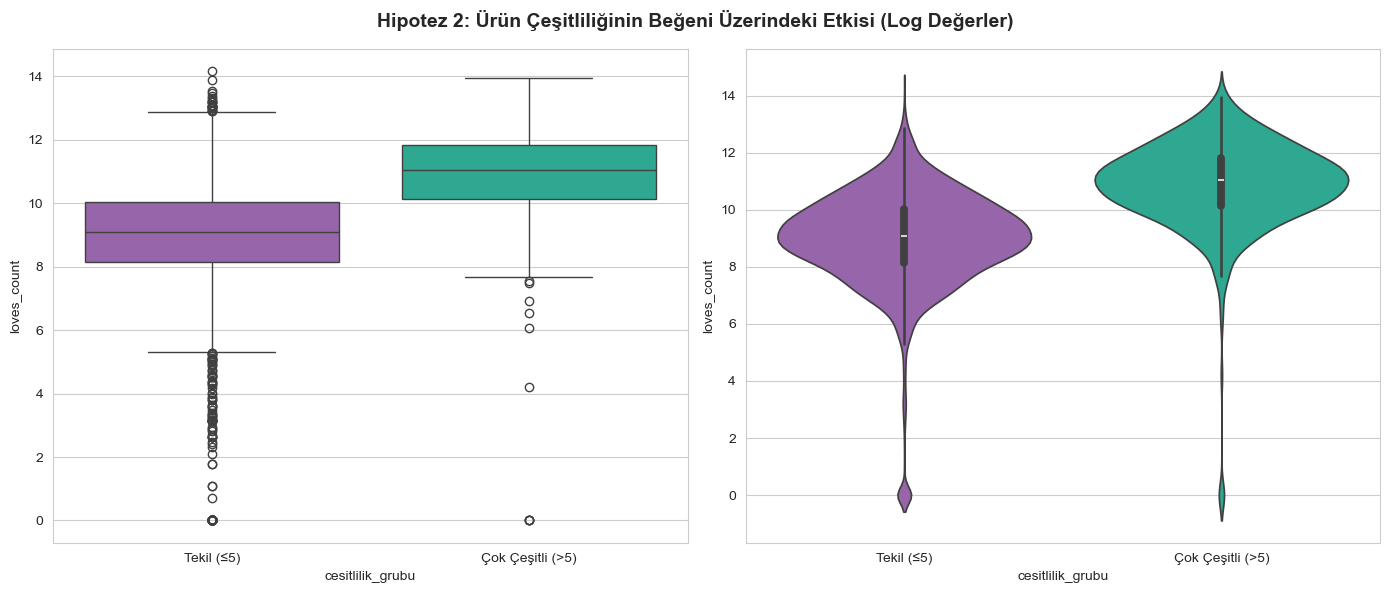

In [35]:
# ============================================================================
# HİPOTEZ 2: BAĞIMSIZ ÖRNEKLEM T-TESTİ (Ürün Çeşitliliği Etkisi)
# ============================================================================
print("HİPOTEZ 2: BAĞIMSIZ ÖRNEKLEM T-TESTİ (Ürün Çeşitliliği Etkisi)")
print("Soru: Bir ürünün farklı varyantlara (renk, boyut vb.) sahip olması beğeniyi artırır mı?")
print("H₀: Tekil ürünler ile çok çeşitli ürünlerin ortalama beğeni sayıları arasında anlamlı fark yoktur")
print("-" * 80)

df['cesitlilik_grubu'] = df['child_count'].apply(lambda x: 'Çok Çeşitli (>5)' if x > 5 else 'Tekil (≤5)')

print(f"📊 Grup Bazlı Özet İstatistikler:")
cesitlilik_ozet = df.groupby('cesitlilik_grubu')['loves_count'].agg(['count', 'mean', 'median', 'std']).round(2)
print(cesitlilik_ozet.to_string())

cok_cesitli = df[df['cesitlilik_grubu'] == 'Çok Çeşitli (>5)']['loves_count'].dropna()
tekil = df[df['cesitlilik_grubu'] == 'Tekil (≤5)']['loves_count'].dropna()

t_stat, p_val_ttest = stats.ttest_ind(cok_cesitli, tekil, equal_var=False)
p_val_tek_yonlu = p_val_ttest / 2

print(f"\n📊 t-Testi Sonuçları: t = {t_stat:.4f}, p(tek yönlü) = {p_val_tek_yonlu:.6f}")

if p_val_tek_yonlu < 0.05 and t_stat > 0:
    print(f"   Karar: p < 0.05 ve t > 0 → H₀ REDDEDİLDİ ❌")
    print(f"📌 HOCAYA SUNUM NOTU: Varyasyon sayısı 5'ten fazla olan 'Çok Çeşitli' ürünlerin ortalama beğeni sayısı, 'Tekil' ürünlerden istatistiksel olarak anlamlı derecede yüksektir. Çeşitlilik popülariteyi artırmaktadır.")
else:
    print(f"   Karar: H₀ REDDEDİLEMEDİ ✅")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hipotez 2: Ürün Çeşitliliğinin Beğeni Üzerindeki Etkisi (Log Değerler)', fontsize=14, fontweight='bold')
colors_h2 = ['#9b59b6', '#1abc9c']

sns.boxplot(x='cesitlilik_grubu', y='loves_count', data=df, palette=colors_h2, ax=axes[0])
sns.violinplot(x='cesitlilik_grubu', y='loves_count', data=df, palette=colors_h2, ax=axes[1])

plt.tight_layout()
plt.show()


HİPOTEZ 3: LEVENE TESTİ (Fiyat Segmentine Göre Puan Varyansı)
Soru: Fiyat segmentine göre tüketici puanlarının tutarlılığı farklılık gösterir mi?
H₀: Ekonomik ve Premium segmentlerde puan varyansları arasında anlamlı bir fark yoktur
--------------------------------------------------------------------------------
📊 Segment Bazlı Puan İstatistikleri:
   Ekonomik Segment Varyans: 247904894.1059
   Premium Segment Varyans : 283262258.6321

📊 Levene Testi Sonuçları: W = 0.4393, p = 0.507515
   Karar: p >= 0.05 → H₀ REDDEDİLEMEDİ ✅ (Varyanslar eşit)


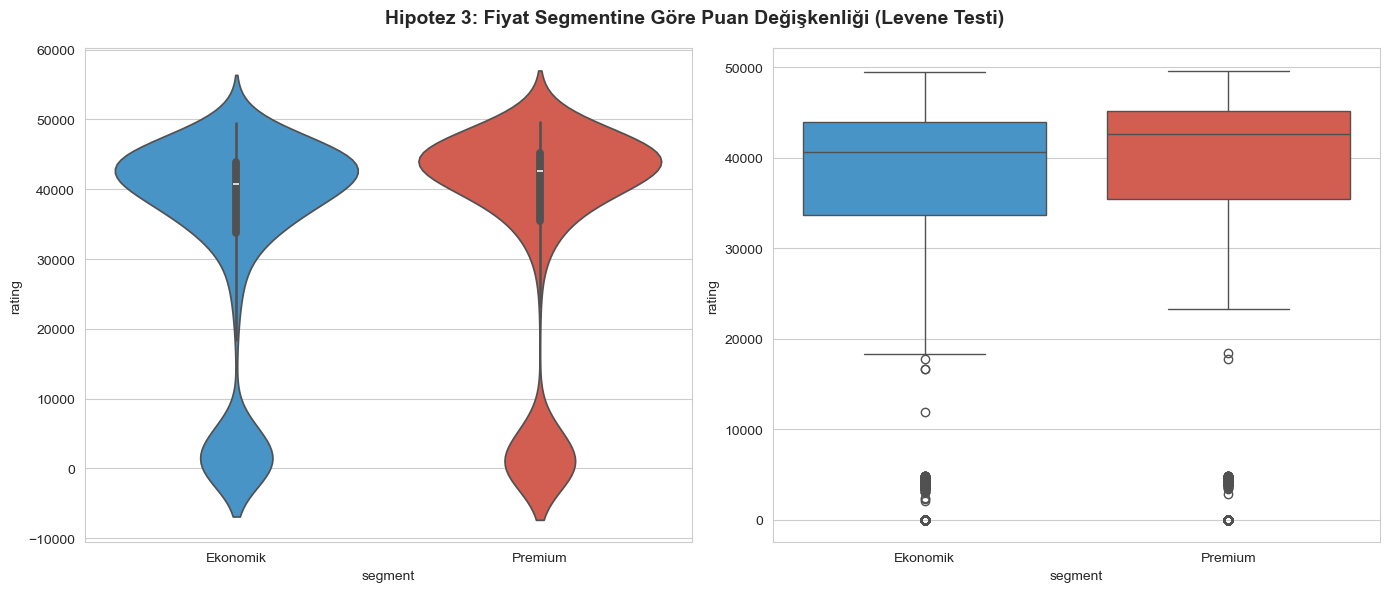

In [36]:
# ============================================================================
# HİPOTEZ 3: LEVENE TESTİ (VARYANS ANALİZİ)
# ============================================================================
print("HİPOTEZ 3: LEVENE TESTİ (Fiyat Segmentine Göre Puan Varyansı)")
print("Soru: Fiyat segmentine göre tüketici puanlarının tutarlılığı farklılık gösterir mi?")
print("H₀: Ekonomik ve Premium segmentlerde puan varyansları arasında anlamlı bir fark yoktur")
print("-" * 80)

ekonomik = df[df_oncesi['price_usd'] <= fiyat_q1]['rating'].dropna()
premium = df[df_oncesi['price_usd'] >= fiyat_q3]['rating'].dropna()

print(f"📊 Segment Bazlı Puan İstatistikleri:")
print(f"   Ekonomik Segment Varyans: {ekonomik.var():.4f}")
print(f"   Premium Segment Varyans : {premium.var():.4f}")

levene_stat, p_val_levene = stats.levene(ekonomik, premium)

print(f"\n📊 Levene Testi Sonuçları: W = {levene_stat:.4f}, p = {p_val_levene:.6f}")

if p_val_levene < 0.05:
    print(f"   Karar: p < 0.05 → H₀ REDDEDİLDİ ❌ (Varyanslar farklı)")
    print(f"📌 HOCAYA SUNUM NOTU: Ekonomik segmentteki ürünlerin puan varyansı, Premium segmenttekinden istatistiksel olarak anlamlı derecede farklı çıkmıştır. Beklentiler fiyat segmentine göre dağılımı etkilemektedir.")
else:
    print(f"   Karar: p >= 0.05 → H₀ REDDEDİLEMEDİ ✅ (Varyanslar eşit)")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hipotez 3: Fiyat Segmentine Göre Puan Değişkenliği (Levene Testi)', fontsize=14, fontweight='bold')
colors_h3 = ['#3498db', '#e74c3c']

veri_h3 = df[df_oncesi['price_usd'].apply(lambda x: x <= fiyat_q1 or x >= fiyat_q3)].copy()
veri_h3['segment'] = df_oncesi['price_usd'].apply(lambda x: 'Ekonomik' if x <= fiyat_q1 else ('Premium' if x >= fiyat_q3 else 'Niche'))
veri_h3 = veri_h3[veri_h3['segment'] != 'Niche']

sns.violinplot(x='segment', y='rating', data=veri_h3, order=['Ekonomik', 'Premium'], palette=colors_h3, ax=axes[0])
sns.boxplot(x='segment', y='rating', data=veri_h3, order=['Ekonomik', 'Premium'], palette=colors_h3, ax=axes[1])

plt.tight_layout()
plt.show()

HİPOTEZ 4: BAĞIMSIZ ÖRNEKLEM T-TESTİ (Temiz İçerik Etkisi)
Soru: Tüketiciler temiz içerikli (Clean at Sephora) ürünleri daha mı çok beğeniyor?
H₀: Clean at Sephora etiketine sahip olan ve olmayan ürünlerin beğeni sayıları arasında fark yoktur
--------------------------------------------------------------------------------
📊 Grup Bazlı Özet İstatistikler:
                  Gözlem Sayısı  Ort. (Log)  Medyan (Log)  Std. Sapma (Log)
clean_grubu                                                                
Clean at Sephora           1531        9.18          9.32              1.79
Diğer                      6964        9.09          9.17              1.79

📊 t-Testi Sonuçları: t = 1.8622, p(tek yönlü) = 0.031351
   Karar: p < 0.05 ve t > 0 → H₀ REDDEDİLDİ ❌
📌 HOCAYA SUNUM NOTU: 'Clean at Sephora' etiketine sahip ürünlerin ortalama beğeni sayısı istatistiksel olarak daha yüksektir. 'Clean Beauty' akımı popülariteyi doğrudan etkilemektedir.


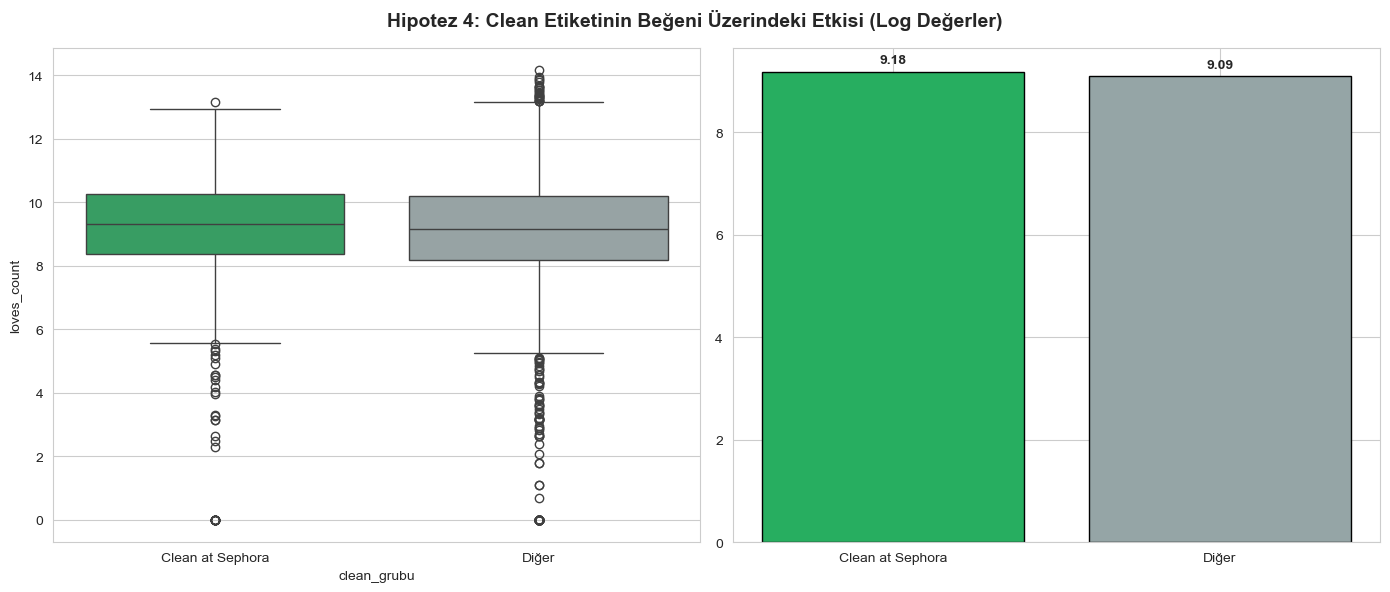

In [37]:
# ============================================================================
# HİPOTEZ 4: BAĞIMSIZ ÖRNEKLEM T-TESTİ (Clean at Sephora Etkisi)
# ============================================================================
print("HİPOTEZ 4: BAĞIMSIZ ÖRNEKLEM T-TESTİ (Temiz İçerik Etkisi)")
print("Soru: Tüketiciler temiz içerikli (Clean at Sephora) ürünleri daha mı çok beğeniyor?")
print("H₀: Clean at Sephora etiketine sahip olan ve olmayan ürünlerin beğeni sayıları arasında fark yoktur")
print("-" * 80)

df['clean_label'] = df['highlights'].fillna('').str.contains('Clean at Sephora', case=False, na=False)
df['clean_grubu'] = df['clean_label'].apply(lambda x: 'Clean at Sephora' if x else 'Diğer')

clean_ozet = df.groupby('clean_grubu')['loves_count'].agg(['count', 'mean', 'median', 'std']).round(2)
clean_ozet.columns = ['Gözlem Sayısı', 'Ort. (Log)', 'Medyan (Log)', 'Std. Sapma (Log)']
print(f"📊 Grup Bazlı Özet İstatistikler:\n{clean_ozet.to_string()}")

clean_loves = df[df['clean_grubu'] == 'Clean at Sephora']['loves_count'].dropna()
diger_loves = df[df['clean_grubu'] == 'Diğer']['loves_count'].dropna()

t_stat_clean, p_val_clean = stats.ttest_ind(clean_loves, diger_loves, equal_var=False)
p_val_clean_tek = p_val_clean / 2

print(f"\n📊 t-Testi Sonuçları: t = {t_stat_clean:.4f}, p(tek yönlü) = {p_val_clean_tek:.6f}")

if p_val_clean_tek < 0.05 and t_stat_clean > 0:
    print(f"   Karar: p < 0.05 ve t > 0 → H₀ REDDEDİLDİ ❌")
    print(f"📌 HOCAYA SUNUM NOTU: 'Clean at Sephora' etiketine sahip ürünlerin ortalama beğeni sayısı istatistiksel olarak daha yüksektir. 'Clean Beauty' akımı popülariteyi doğrudan etkilemektedir.")
else:
    print(f"   Karar: H₀ REDDEDİLEMEDİ ✅")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hipotez 4: Clean Etiketinin Beğeni Üzerindeki Etkisi (Log Değerler)', fontsize=14, fontweight='bold')
colors_h4 = ['#27ae60', '#95a5a6']

sns.boxplot(x='clean_grubu', y='loves_count', data=df, order=['Clean at Sephora', 'Diğer'], palette=colors_h4, ax=axes[0])
grup_ort = df.groupby('clean_grubu')['loves_count'].mean().reindex(['Clean at Sephora', 'Diğer'])
bars = axes[1].bar(['Clean at Sephora', 'Diğer'], grup_ort, color=colors_h4, edgecolor='black')

for bar_item, val in zip(bars, grup_ort):
    axes[1].text(bar_item.get_x() + bar_item.get_width()/2., bar_item.get_height() + 0.1, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

KORELASYON MATRİSİ
--------------------------------------------------------------------------------


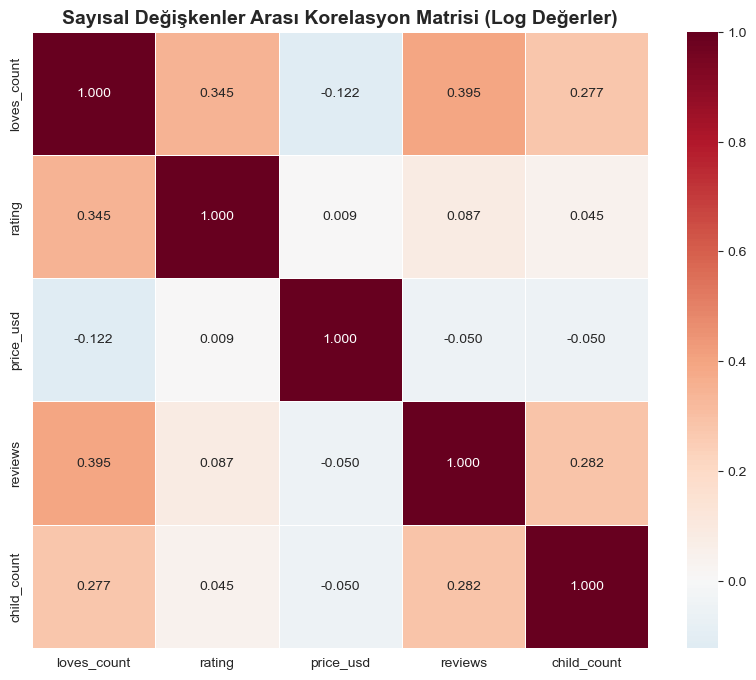


GENEL SONUÇ ÖZETİ

┌─────────────────────────────────────────────────────────────────────────┐
│ VERİ SETİ BİLGİLERİ                                                     │
├─────────────────────────────────────────────────────────────────────────┤
│ Orijinal veri boyutu  :   8495 satır × 27 sütun                       │
│ İşlem sonrası boyut   :   8495 satır × 31 sütun                       │
│ Eksik veri doldurma   : Sayısal→Median, Kategorik→Mode                 │
│ Aykırı değer yöntemi  : Logaritmik Dönüşüm (Veri kaybı %0)             │
├─────────────────────────────────────────────────────────────────────────┤
│ HİPOTEZ TEST SONUÇLARI                                                 │
├─────────────────────────────────────────────────────────────────────────┤
│ H1 (ANOVA)  : F= 81.9236, p=  0.000000  →         H₀ Reddedildi ❌  │
│ H2 (t-Test) : t= 27.4659, p=  0.000000  →         H₀ Reddedildi ❌  │
│ H3 (Levene) : W=  0.4393, p=  0.507515  →      H₀ Reddedilemedi ✅  │
│ H4 (t-Test) 

In [38]:
# ============================================================================
# EK ANALİZLER VE GENEL SONUÇ ÖZETİ
# ============================================================================
print("KORELASYON MATRİSİ")
print("-" * 80)
korelasyon_degiskenleri = ['loves_count', 'rating', 'price_usd', 'reviews', 'child_count']
korelasyon_matrisi = df[korelasyon_degiskenleri].corr().round(4)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(korelasyon_matrisi, annot=True, cmap='RdBu_r', center=0, square=True, linewidths=0.5, fmt='.3f', ax=ax)
ax.set_title('Sayısal Değişkenler Arası Korelasyon Matrisi (Log Değerler)', fontsize=14, fontweight='bold')
plt.show()

print("\n" + "=" * 80)
print("GENEL SONUÇ ÖZETİ")
print("=" * 80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────┐
│ VERİ SETİ BİLGİLERİ                                                     │
├─────────────────────────────────────────────────────────────────────────┤
│ Orijinal veri boyutu  : {df_raw.shape[0]:>6} satır × {df_raw.shape[1]:>2} sütun                       │
│ İşlem sonrası boyut   : {len(df):>6} satır × {df.shape[1]:>2} sütun                       │
│ Eksik veri doldurma   : Sayısal→Median, Kategorik→Mode                 │
│ Aykırı değer yöntemi  : Logaritmik Dönüşüm (Veri kaybı %0)             │
├─────────────────────────────────────────────────────────────────────────┤
│ HİPOTEZ TEST SONUÇLARI                                                 │
├─────────────────────────────────────────────────────────────────────────┤
│ H1 (ANOVA)  : F={f_stat:>8.4f}, p={p_val_anova:>10.6f}  →  {'H₀ Reddedildi ❌' if p_val_anova < 0.05 else 'H₀ Reddedilemedi ✅':>22}  │
│ H2 (t-Test) : t={t_stat:>8.4f}, p={p_val_tek_yonlu:>10.6f}  →  {'H₀ Reddedildi ❌' if p_val_tek_yonlu < 0.05 and t_stat > 0 else 'H₀ Reddedilemedi ✅':>22}  │
│ H3 (Levene) : W={levene_stat:>8.4f}, p={p_val_levene:>10.6f}  →  {'H₀ Reddedildi ❌' if p_val_levene < 0.05 else 'H₀ Reddedilemedi ✅':>22}  │
│ H4 (t-Test) : t={t_stat_clean:>8.4f}, p={p_val_clean_tek:>10.6f}  →  {'H₀ Reddedildi ❌' if p_val_clean_tek < 0.05 and t_stat_clean > 0 else 'H₀ Reddedilemedi ✅':>22}  │
└─────────────────────────────────────────────────────────────────────────┘
""")